# Abhishek Kothari
# DS 5230 Final Exam 

### Question 1

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from umap.umap_ import UMAP 
from scipy.ndimage import gaussian_filter

In [3]:
data = np.loadtxt("pb1data_XW_8358.txt", delimiter=",")
labels = data[:, 0].astype(int) # these are the true labels
X = data[:, 1:] # these are the features

In [5]:
X

array([[ 53.,  40., 119., ...,  53.,  17.,  88.],
       [ 42., 100.,  31., ...,  38.,  36.,  78.],
       [ 60.,  10.,  16., ...,  76.,  61.,  28.],
       ...,
       [ 41.,  37.,  40., ..., 113., 141.,  86.],
       [107., 122., 118., ...,  45., 123.,   8.],
       [ 93.,  16.,  50., ...,   5.,  20.,  17.]])

In [7]:
print(f"The count of x is: {len(X)}")

The count of x is: 8358


In [11]:
print(f"The count of y is: {len(labels)}")

The count of y is: 8358


In [13]:
# we smoothen out the features using a gaussian filter
X_smoothed = np.array([gaussian_filter(x.reshape(28, 28), sigma=0.7).flatten() for x in X])

In [15]:
# lets reduce the dimensions of these smoothened features
X_pca = PCA(n_components=45, random_state=42).fit_transform(X_smoothed)

In [17]:
# in order to further reduce the dimentions and keep the structural integrity we use umap
X_umap = UMAP(n_neighbors=20, min_dist=0.0, n_components=5, metric = 'euclidean',random_state=42).fit_transform(X_pca)

/Users/DELL/anaconda3/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/DELL/anaconda3/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
# now we pass this preprocessed data into our clustering algorithm
agglo = AgglomerativeClustering(n_clusters=10, linkage = 'ward')
clusters = agglo.fit_predict(X_umap)

In [23]:
def evaluate(true_labels: np.ndarray, pred_labels: np.ndarray) -> tuple:
  """Entropy-based evaluation of a label assignment.
 
  Parameters:
    true_labels: the ground-truth class labels on the input data.
    pred_labels: the predicted class labels on the input data.
 
  Returns:
    a tuple (CM, (cs_e, cr_e, we)) containing the confusion matrix `CM`, the class entropies `cs_e`,
    the cluster entropies `cr_e`, and the averaged weighted entropies `we`.
  """
  from scipy.stats import entropy
 
  assert len(true_labels) == len(pred_labels), "Label predictions don't match"
 
  ## Map the labels to index set {0, 1, ..., k - 1 }
  t_classes, t_labels = np.unique(true_labels, return_inverse=True)
  p_classes, p_labels = np.unique(pred_labels, return_inverse=True)
  assert np.all(np.isin(p_classes, t_classes)), "Predicted class outside of labels given"
 
  ## Accumulate the counts
  n_classes = len(t_classes)
  CM = np.zeros(shape=(n_classes, n_classes), dtype=np.uint32)
  ind = np.ravel_multi_index([t_labels, p_labels], CM.shape)
  np.add.at(CM.ravel(), ind, 1)
 
  ## Compute the entropy of the empirical row/column distributions
  empirical_dist = lambda x: x / np.sum(x)
  cluster_entropy = np.apply_along_axis(lambda x: entropy(empirical_dist(x), base=2), 0, CM)
  class_entropy = np.apply_along_axis(lambda x: entropy(empirical_dist(x), base=2), 1, CM)
 
  ## Average w/ count weights
  w_cluster_entropy = np.sum(cluster_entropy * CM.sum(axis=0)) / len(true_labels)
  w_class_entropy = np.sum(class_entropy * CM.sum(axis=1)) / len(true_labels)
  w_entropies = np.array([w_class_entropy, w_cluster_entropy])
 
  with np.printoptions(precision=3):
    print(f"Class Entropies: {class_entropy}")
    print(f"Cluster Entropies: {cluster_entropy}")
    print(f"Weighted average entropies: {w_entropies}, (avg: {np.mean(w_entropies):.3f})")
  return CM, (w_class_entropy, w_cluster_entropy, w_entropies)

In [25]:
# now we evaluate based on the given function
evaluate(labels,clusters)

Class Entropies: [0.078 1.033 0.869 0.619 0.184 1.29  0.218 0.543 0.7   0.48 ]
Cluster Entropies: [1.176 0.388 1.32  0.516 0.331 0.325 0.357 0.388 0.506 0.287]
Weighted average entropies: [0.67 0.71], (avg: 0.690)


(array([[   1,    0,    0,    1,    1,    0,    0,    2,    0,  667],
        [   5, 1031,    3,    0,    1,    8,  530,    1,    1,    0],
        [  17,    4,   14,    0,    1,  429,    5,    4,   12,    4],
        [ 933,   12,   10,   39,    4,    7,    3,    2,    7,    1],
        [   0,    5,  943,    1,    1,    1,    2,    5,    1,    2],
        [  17,    2,   11,  700,  457,    0,    0,   20,    1,    5],
        [   1,    1,    1,    5,    2,    0,    2,  711,    0,    5],
        [   0,   12,   23,    0,    0,    3,    3,    0,  473,    1],
        [ 446,    4,   17,    9,    9,    0,    7,    3,    0,    0],
        [  11,    9,  643,    4,    0,    0,    1,    0,   14,    4]],
       dtype=uint32),
 (0.669580169452982, 0.71040401725457, array([0.66958017, 0.71040402])))

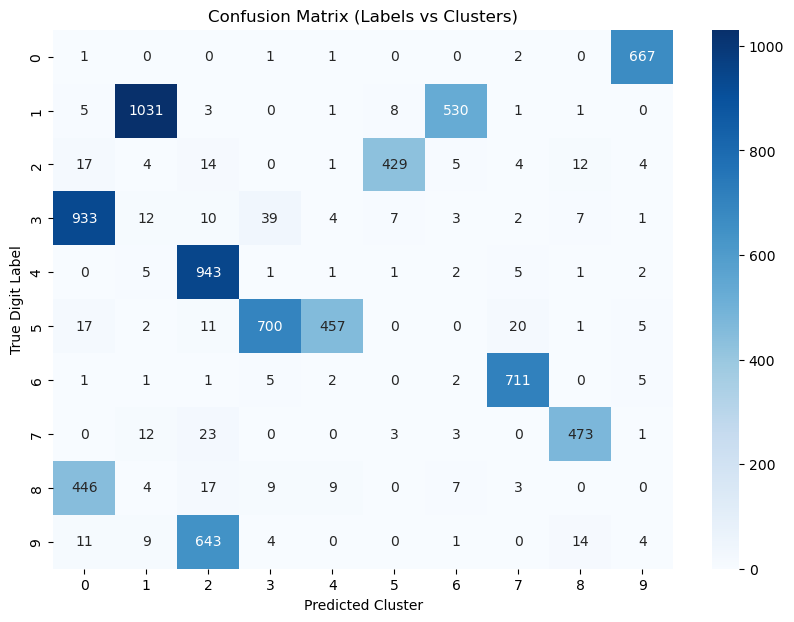

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
conf_mat = confusion_matrix(labels, clusters)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Labels vs Clusters)")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Digit Label")
plt.show()

I tried a lot of different combinations. i tried scaling the data using the standard scalar, but i found that using the gaussian filter was giving me much better results. For dimensionality reduction as well, i tried a lot of things, right from using just the pca or pca along with tsne or just the tsne as well. But i found the combination of pca along with umap gave me the best output. I also played a lot with the parameters, and after performing some random combinations and also a short grid search, i found that this was the best possible combination for my use case. 

### Question 2

##### Part A)

Since the bidding process for each product class is independent and occurs at a constant average rate (lambda), I modeled the number of bids per day using a Poisson distribution. However, because I didn’t know which class was auctioned on which day, I treated the data as a mixture of four Poisson distributions, each representing a different product class. Based on this assumption, I implemented the Expectation-Maximization (EM) algorithm to estimate the lambda values and class proportions that best explain the observed bid counts across the 10,000 recorded days.

##### Part B)

In [39]:
from scipy.stats import poisson

In [41]:
data = np.loadtxt("pb2data_D.txt")  
N = data.shape[0]
K = 4  # Number of product classes

In [43]:
np.random.seed(42)
lambdas = np.random.uniform(2, 20, K)
weights = np.ones(K) / K

In [45]:
max_iter = 100
tol = 1e-4
log_likelihoods = []

for iteration in range(max_iter):
    # E-step: compute responsibilities
    gamma = np.zeros((N, K))
    for j in range(K):
        gamma[:, j] = weights[j] * poisson.pmf(data, mu=lambdas[j]) # for every data point and every class, how likely is that the data point came from that class
    gamma_sum = np.sum(gamma, axis=1, keepdims=True) # we sume the un-normalized probabilities
    gamma /= gamma_sum  # normalized probability distribution

    # M-step: update weights and lambdas
    weights_new = np.sum(gamma, axis=0) / N # how responsible each class was for each data point
    lambdas_new = np.sum(gamma * data[:, np.newaxis], axis=0) / np.sum(gamma, axis=0) # here we get weighted avg of bids where weights are the class probabilities

    # Log-likelihood
    log_likelihood = np.sum(np.log(np.sum([ weights[j] * poisson.pmf(data, mu=lambdas[j]) for j in range(K)], axis=0)))
    log_likelihoods.append(log_likelihood)

    # Convergence check
    if np.linalg.norm(lambdas_new - lambdas) < tol and np.linalg.norm(weights_new - weights) < tol: # we check if we need to perform more iteration or our tolerance has reached
        print(f"Converged in {iteration + 1} iterations.")
        break

    lambdas = lambdas_new
    weights = weights_new

In [47]:
final_assignments = np.argmax(gamma, axis=1)
estimated_days = np.bincount(final_assignments, minlength=K)

print("\nEstimated lambda (bidding rates):", np.round(lambdas, 2))
print("Estimated days per class:", estimated_days)


Estimated lambda (bidding rates): [ 2.01 22.51 15.86  6.22]
Estimated days per class: [2108 3759 1031 3102]


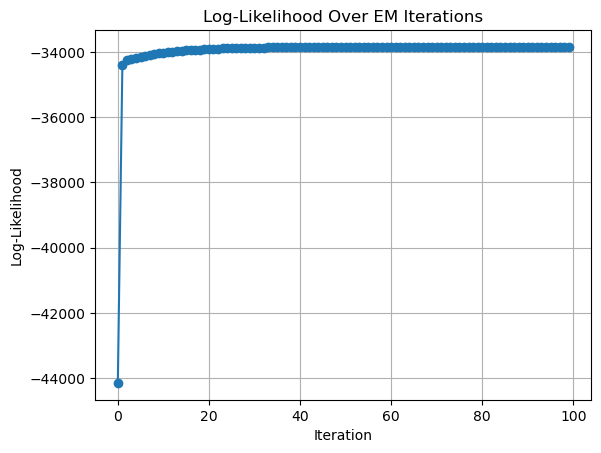

In [49]:
plt.plot(log_likelihoods, marker='o')
plt.title("Log-Likelihood Over EM Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()